In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import torch
import os
import math
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process
from tqdm import tqdm

plt.rcParams.update({
    "text.usetex": True,  # Enable LaTeX rendering
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"], # Specify the font (classic LaTeX font)
    # You might need to adjust the font paths or preamble depending on your setup
    # "text.latex.preamble": r"\usepackage{amsmath}" # Example if you need math packages
})

### Testing the distribution of counts of upcrossings, downcrossings and crossings.

In [6]:
crossing_type = "upcrossing"  
# crossing_type = "downcrossing"
# crossing_type = "crossing"
ModelClass = formula.GaussianUpCrossings

count_method = getattr(utils, f"count_{crossing_type}s")
mean_rate_method = f"{crossing_type}_mean_rate"
mean_method = f"{crossing_type}_mean"
variance_method = f"{crossing_type}_variance"
variance_method_CLT = f"{crossing_type}_variance_CLT"
fano_method = f"{crossing_type}_fano_factor"
fano_method_CLT = f"{crossing_type}_fano_factor_CLT"

In [7]:
if crossing_type == "downcrossing":
    fano_label = r'$\mathrm{F}^\downarrow$'
elif crossing_type == "upcrossing":
    fano_label = r'$\mathrm{F}^\uparrow$'
else:
    fano_label = r'$\mathrm{F}$'

In [8]:
# Simulation parameters.
T = 20.0                        # Total simulation time.
omega0 = math.sqrt(10.0)                   # Fundamental frequency
zeta = 0.5                      # Damping ratio
temp = 10.0                     # Temperature (similar to sigma ** 2)

if zeta < 1.0:
    dt = 0.01 / (omega0 * max(zeta, math.sqrt(1 - zeta**2)))  
elif zeta == 1.0:
    dt = 0.01 / omega0
else:
    dt = 0.01 / (omega0 * max(zeta + math.sqrt(zeta**2 - 1), zeta - math.sqrt(zeta**2 - 1)))
    

u = 0.0                         # Threshold
n_trials = 1000                  # Number of simulation trials.

# Containers for simulation results.
counts = np.zeros(n_trials, dtype=int)

# Run the simulations.
for trial in range(n_trials):
    # Simulate one sample path of the process.
    t, x = utils.simulate_gaussian_process_fft(
        process.r_damped_harmonic_oscillator_noise, T, dt, temp=temp, zeta=zeta, omega0=omega0
    )
    # Count the number of {crossing_type} at threshold u.
    counts[trial] = count_method(x, threshold=u)

# Calculate empirical statistics.
sim_mean = np.mean(counts)
sim_var = np.var(counts)
sim_fano = sim_var / sim_mean if sim_mean != 0 else np.nan

print("Simulation results:")
print(f"Mean {crossing_type}: {sim_mean:.4f}")
print(f"Variance of {crossing_type}: {sim_var:.4f}")
print(f"Fano factor (variance/mean): {sim_fano:.4f}")

Simulation results:
Mean upcrossing: 10.0290
Variance of upcrossing: 3.6562
Fano factor (variance/mean): 0.3646


In [9]:
# Compute analytical results using your GaussianUpCrossingsDimless class.
# (Note: the analytical formulas assume a dimensionless time scale with tau set to 1 in r(t).
# Here we pass tau=tau_e to keep parameters consistent with the simulation.)
model = ModelClass(r_func=process.r_damped_harmonic_oscillator_noise, u=u, temp=temp, zeta=zeta, omega0=omega0)

analytical_mean = getattr(model, mean_method)(T, u=u).item()
analytical_variance = getattr(model, variance_method)(T, u=u).item()
analytical_fano = getattr(model, fano_method)(T, u=u).item()

print("\nAnalytical results:")
print(f"Expected number of {crossing_type} (mean): {analytical_mean:.4f}")
print(f"Variance of {crossing_type}: {analytical_variance:.4f}")
print(f"Fano factor (variance/mean): {analytical_fano:.4f}")

# print the CLT results as well
analytical_variance_CLT = getattr(model, variance_method_CLT)(T, u=u).item()
analytical_fano_CLT = getattr(model, fano_method_CLT)(u=u).item()

print("\nAnalytical results using CLT:")
print(f"Variance of {crossing_type}: {analytical_variance_CLT:.4f}")
print(f"Fano factor (variance/mean): {analytical_fano_CLT:.4f}")




Analytical results:
Expected number of upcrossing (mean): 10.0658
Variance of upcrossing: 3.5545
Fano factor (variance/mean): 0.3531

Analytical results using CLT:
Variance of upcrossing: 3.4074
Fano factor (variance/mean): 0.3385


In [10]:
covariance_up_down = model.crossing_variance(T, u=u).item() / 2 - model.upcrossing_variance(T, u=u).item()

print(model.upcrossing_variance(T, u=u).item())
print(model.downcrossing_variance(T, u=u).item())
print(model.crossing_variance(T, u=u).item())
print(covariance_up_down)

# how correlated are up and down crossing processes?
print(covariance_up_down / model.upcrossing_variance(T, u=u).item())

3.5544545564187526
3.5544545564187526
13.717440754885676
3.304265821024085
0.9296126222959108


In [11]:
covariance_up_down_CLT = model.crossing_variance_CLT(T, u=u).item() / 2 - model.upcrossing_variance_CLT(T, u=u).item()
print(model.upcrossing_variance_CLT(T, u=u).item())
print(model.downcrossing_variance_CLT(T, u=u).item())
print(model.crossing_variance_CLT(T, u=u).item())
print(covariance_up_down_CLT)

# how correlated are up and down crossing processes?
print(covariance_up_down_CLT / model.upcrossing_variance_CLT(T, u=u).item())

3.4074259531567455
3.4074259531567455
13.629317960907459
3.407233027296984
0.9999433807623661


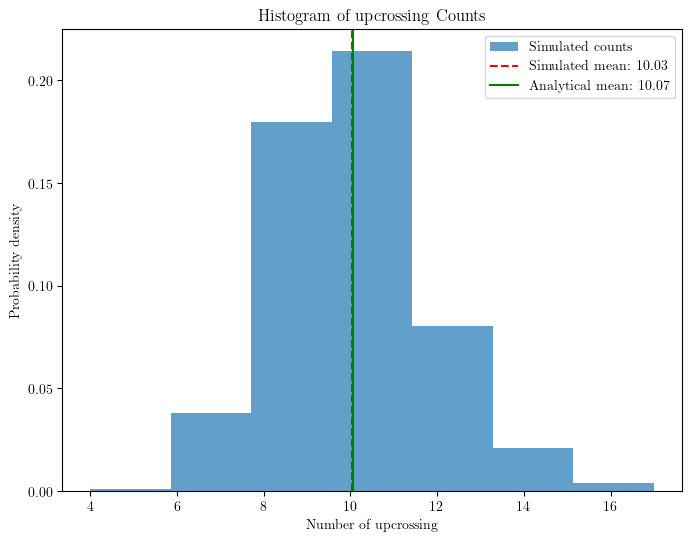

In [12]:
# Plot histogram of simulation counts with the analytical mean indicated.
plt.figure(figsize=(8, 6))
plt.hist(counts, bins=(max(counts)-min(counts)+1)//2, density=True, alpha=0.7, label="Simulated counts")
plt.axvline(sim_mean, color='r', linestyle='--', 
            label=f"Simulated mean: {sim_mean:.2f}")
plt.axvline(analytical_mean, color='g', linestyle='-', 
            label=f"Analytical mean: {analytical_mean:.2f}")
plt.xlabel(f"Number of {crossing_type}")
plt.ylabel("Probability density")
plt.title(f"Histogram of {crossing_type} Counts")
plt.legend()
plt.show()

### We simulate the analytical vs simulation results for Fano factors.

In [13]:
# which process to use
r_func = process.r_damped_harmonic_oscillator_noise

# define the parameters of the model
T = 50.0                # Total simulation time.
omega0 = math.sqrt(10.0)                   # Fundamental frequency
zeta = 0.5                      # Damping ratio
temp = 10.0                     # Temperature (similar to sigma ** 2)

params = {
    'omega0': omega0,
    'zeta': zeta, # this will be updated below
    'temp': temp,
}

In [14]:
# define the values of u for which the result is wanted
u_list = [0.0, 0.25, 0.5]

# define the zeta values 
num_points_zeta = 50
zeta_min = 0.25
zeta_max = 0.99
zeta_vals = torch.logspace(np.log10(zeta_min), np.log10(zeta_max), num_points_zeta)


In [15]:
# -------------------------------------------
# Save analytical results in a dictionary.
# -------------------------------------------
analytical_results = {}  # Keys are threshold u values.

for u in u_list:
    mean_vals = []
    variance_vals = []
    fano_vals = []
    
    for zeta in zeta_vals:
        zeta_val = float(zeta)
        params['zeta'] = zeta_val
        
        # Create GaussianUpCrossingsDimless instance with current parameters.
        model = ModelClass(r_func=r_func, u=u, **params)
        
        # Compute analytical quantities.
        mean_vals.append(getattr(model, mean_method)(T, u=u).item())
        variance_vals.append(getattr(model, variance_method)(T, u=u).item())
        fano_vals.append(getattr(model, fano_method)(T, u=u).item())
        # fano_vals.append(getattr(model, fano_method_CLT)(u=u).item())
    
    # Convert lists to torch tensors.
    analytical_results[u] = {
        'mean': torch.tensor(mean_vals),
        'variance': torch.tensor(variance_vals),
        'fano_factor': torch.tensor(fano_vals),
    }

In [16]:
# --------------------------------------------------
# Compute simulation results (using FFT simulations) and store in dictionary.
# --------------------------------------------------
# Define simulation-specific parameters.
n_trials = 2000  # Number of simulation trials.

# Define the zeta values.
num_points_zeta_sim = 5
zeta_vals_sim = torch.logspace(np.log10(zeta_min), np.log10(zeta_max), num_points_zeta_sim)

simulation_results = {u: {} for u in u_list}  # Prepare dictionary keys for each threshold.

# For each zeta value, simulate trials and compute counts for all thresholds at once.
for zeta in tqdm(zeta_vals_sim, desc="Simulating over zeta values"):
    zeta_val = float(zeta)
    params['zeta'] = zeta_val

    if zeta_val < 1.0:
        dt = 0.01 / (omega0 * max(zeta_val, math.sqrt(1 - zeta_val**2)))  # Time discretization step.
    elif zeta_val == 1.0:
        dt = 0.01 / omega0
    else:
        dt = 0.01 / (omega0 * max(zeta_val + math.sqrt(zeta_val**2 - 1), zeta_val - math.sqrt(zeta_val**2 - 1)))  # Time discretization step.
    
    # Create an array to store counts for each trial and each threshold.
    # The second dimension corresponds to each threshold in u_list.
    counts = np.zeros((n_trials, len(u_list)))
    
    for trial in tqdm(range(n_trials), desc="Trials", leave=False):
        # Generate one sample path using FFT-based simulation.
        t, x = utils.simulate_gaussian_process_fft(r_func, T, dt, **params)
        
        # Compute counts for all thresholds in one call   
        count = count_method(x, threshold=u_list)  # returns a list of counts
        
        counts[trial, :] = count
    
    # Compute simulation statistics for each threshold.
    sim_mean = np.mean(counts, axis=0)
    sim_var = np.var(counts, axis=0)
    # Compute Fano factor while avoiding division by zero.
    sim_fano = np.divide(sim_var, sim_mean, out=np.full_like(sim_var, np.nan), where=(sim_mean != 0))
    
    # Append the statistics to the results dictionary for each threshold.
    for i, u in enumerate(u_list):
        # If results for the current threshold already exist, append the new value.
        # Otherwise, initialize as a list.
        simulation_results[u].setdefault('mean', []).append(sim_mean[i])
        simulation_results[u].setdefault('variance', []).append(sim_var[i])
        simulation_results[u].setdefault('fano_factor', []).append(sim_fano[i])

# Convert lists to torch tensors for each threshold.
for u in simulation_results:
    simulation_results[u]['mean'] = torch.tensor(simulation_results[u]['mean'])
    simulation_results[u]['variance'] = torch.tensor(simulation_results[u]['variance'])
    simulation_results[u]['fano_factor'] = torch.tensor(simulation_results[u]['fano_factor'])


Simulating over zeta values:   0%|          | 0/5 [00:00<?, ?it/s]

Simulating over zeta values: 100%|██████████| 5/5 [00:50<00:00, 10.08s/it]


In [18]:
axis_label_fontsize = 28 # Fontsize for x and y labels & titles
tick_label_fontsize = 24 # Fontsize for tick labels
legend_fontsize = 24     # Fontsize for legend (matched to tick labels)
# num_x_ticks = 6        # Not directly used due to LogLocator
num_y_ticks = 4          # Desired number of ticks on the y-axis
tick_line_width = 2.0    # Thickness of tick lines
spine_line_width = 2.0   # Thickness of plot border

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


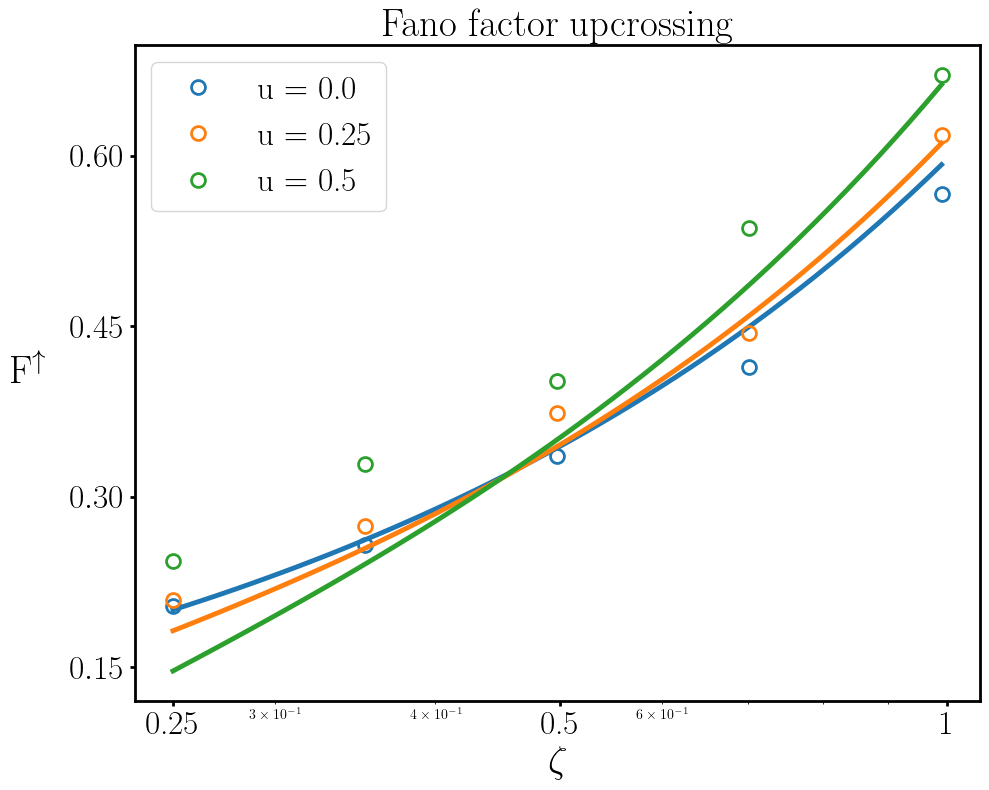

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))

# Use the user's specified colormap
colors = plt.get_cmap("tab10")

for i, u in enumerate(u_list):
    analytical_fano = analytical_results[u]['fano_factor'] 
    simulation_fano = simulation_results[u]['fano_factor'] 

    # Plot the analytical curve with a thicker solid line. (User's linewidth=3)
    ax.plot(zeta_vals, analytical_fano, linewidth=3.5, linestyle='-', color=colors(i), label='_nolegend_')

    # Plot the simulation results as open circles in the same color. (User's marker settings)
    ax.plot(zeta_vals_sim, simulation_fano, marker='o', markersize=10, linestyle='None',
            color=colors(i), markerfacecolor='none', markeredgewidth=2, label=f"u = {u}") # Keep label format

# Apply new font sizes to title and labels
ax.set_title(f"Fano factor {crossing_type}", fontsize=axis_label_fontsize)
ax.set_xlabel(r"$\zeta$", fontsize=axis_label_fontsize)
ax.set_ylabel(fano_label, fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=30) # Added rotation/padding like before
ax.set_xscale('log')  # Use a logarithmic scale for the x-axis (User's choice)

# Apply new tick label size and tick line width
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

# Keep user's specific tick formatters/locators but adjust y-axis tick count
# Use FuncFormatter to display plain numbers on the x-axis.
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(mticker.LogLocator(base=2.0, numticks=3)) 
ax.yaxis.set_major_locator(mticker.MaxNLocator(num_y_ticks))

# Apply new spine width settings
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)

# Only add the legend for simulation markers, apply new font size
ax.legend(fontsize=legend_fontsize)
plt.tight_layout() 

#save the figure
folder_loc = f'../../figures/damped_harmonic_oscillator/'
os.makedirs(folder_loc, exist_ok=True)
file_name = f'theory_sim_fano_{crossing_type}' 
file_save_path = os.path.join(folder_loc, file_name)
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


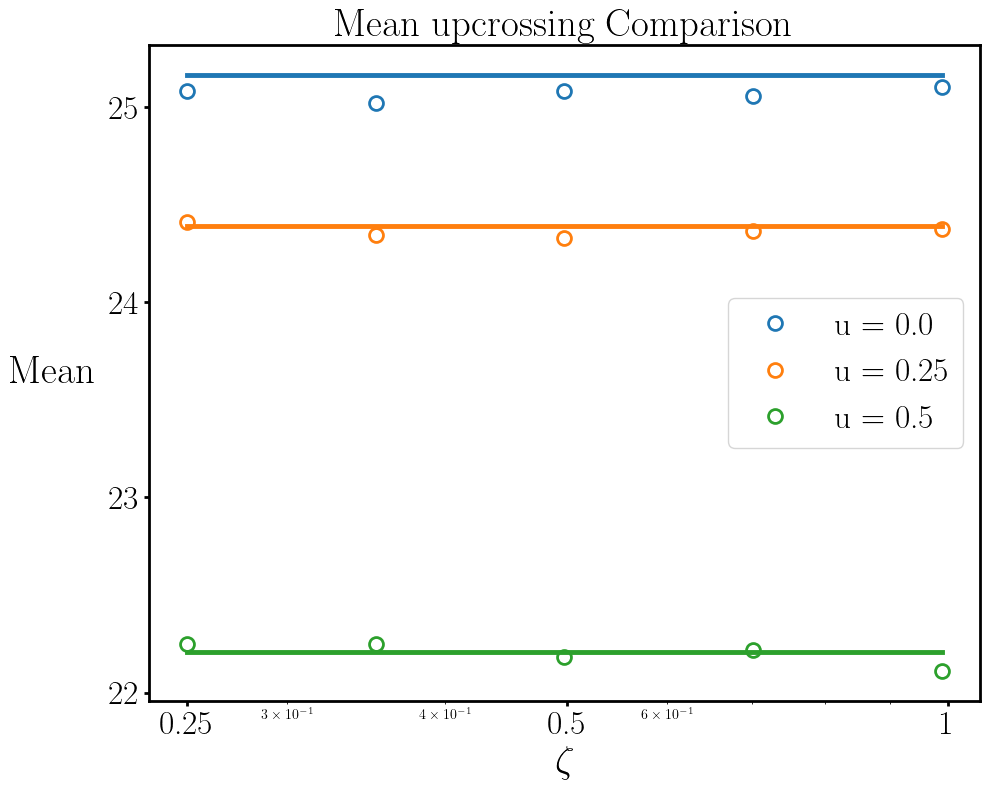

In [22]:
fig, ax = plt.subplots(figsize=(10, 8)) # Use target figure size

# Use the target colormap
colors = plt.get_cmap("tab10")

# Loop using enumerate to get index for colors, matching the target style
for i, u in enumerate(u_list):
    analytical_mean = analytical_results[u]['mean']
    simulation_mean = simulation_results[u]['mean']

    # Plot the analytical curve with a thicker solid line (target linewidth=3.5)
    ax.plot(zeta_vals, analytical_mean, linewidth=3.5, linestyle='-', color=colors(i), label='_nolegend_')

    # Plot the simulation results as open circles in the same color (target marker settings)
    ax.plot(zeta_vals_sim, simulation_mean, marker='o', markersize=10, linestyle='None',
            color=colors(i), markerfacecolor='none', markeredgewidth=2, label=f"u = {u}") # Keep label format

# Apply new font sizes to title and labels
ax.set_title(f"Mean {crossing_type} Comparison", fontsize=axis_label_fontsize) # Simplified title slightly
ax.set_xlabel(r"$\zeta$", fontsize=axis_label_fontsize) # Use LaTeX tau
ax.set_ylabel("Mean", fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=40) # Added rotation/padding

ax.set_xscale('log') # Keep logarithmic scale for the x-axis

# Apply new tick label size and tick line width
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

# Keep specific tick formatters/locators but use mticker prefix and adjust y-axis ticks
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(mticker.LogLocator(base=2.0, numticks=5)) # Keep base 2 log locator
ax.yaxis.set_major_locator(mticker.MaxNLocator(num_y_ticks)) # Use num_y_ticks variable

# Apply new spine width settings
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)

# Only add the legend for simulation markers, apply new font size
ax.legend(fontsize=legend_fontsize)
plt.tight_layout()

# --- Save the figure in multiple formats ---
# Define the folder and filename structure (adjust path as needed)
folder_loc = f'../../figures/damped_harmonic_oscillator/' # Assuming same folder structure
os.makedirs(folder_loc, exist_ok=True)
file_name = f'theory_sim_mean_{crossing_type}' # Changed 'fano' to 'mean'
file_save_path = os.path.join(folder_loc, file_name)

# Save in PNG, SVG, EPS formats with specified settings
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


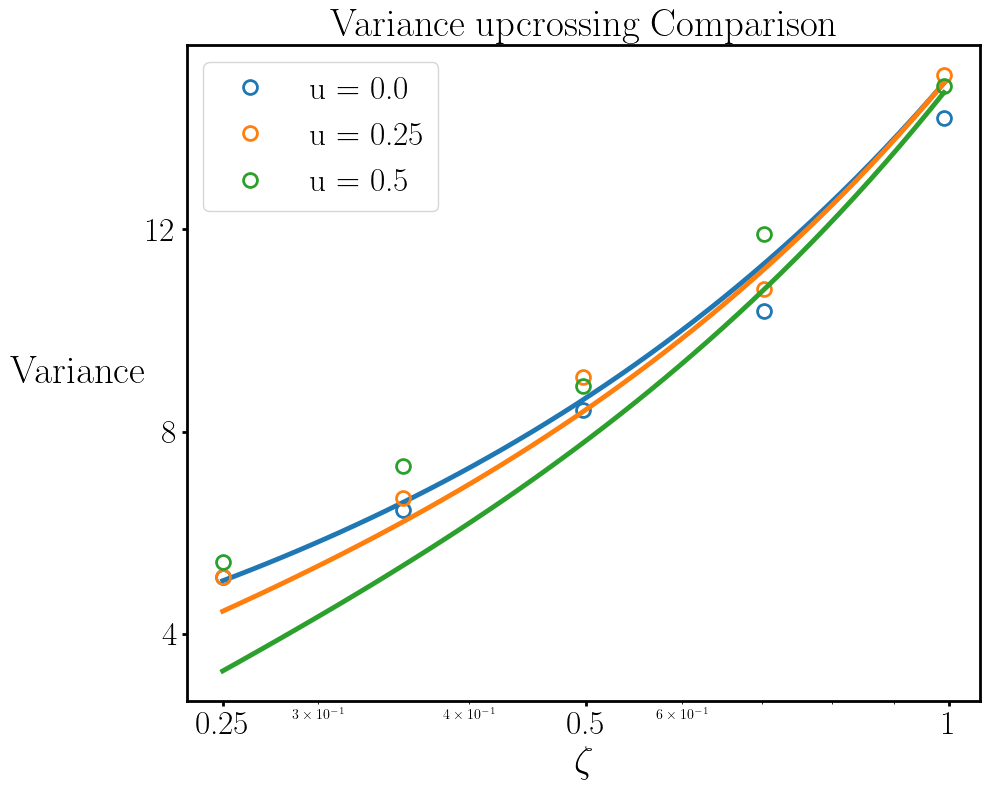

In [23]:
fig, ax = plt.subplots(figsize=(10, 8)) # Use target figure size

# Use the target colormap
colors = plt.get_cmap("tab10")

# Loop using enumerate to get index for colors, matching the target style
for i, u in enumerate(u_list):
    # Access data directly (assuming numpy arrays based on your ideal example)
    analytical_variance = analytical_results[u]['variance']
    simulation_variance = simulation_results[u]['variance']

    # Plot the analytical curve with target style (linewidth=3.5)
    ax.plot(zeta_vals, analytical_variance, linewidth=3.5, linestyle='-', color=colors(i), label='_nolegend_')

    # Plot the simulation results with target style (markersize=10)
    ax.plot(zeta_vals_sim, simulation_variance, marker='o', markersize=10, linestyle='None',
            color=colors(i), markerfacecolor='none', markeredgewidth=2, label=f"u = {u}") # Keep label format

# Apply new font sizes and format to title and labels
ax.set_title(f"Variance {crossing_type} Comparison", fontsize=axis_label_fontsize) # Adjusted title
ax.set_xlabel(r"$\zeta$", fontsize=axis_label_fontsize) # Use LaTeX tau
ax.set_ylabel("Variance", fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=50) # Adjusted label, padding

ax.set_xscale('log') # Keep logarithmic scale for the x-axis

# Apply target tick label size and tick line width
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

# Apply target tick formatters/locators using mticker
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(mticker.LogLocator(base=2.0, numticks=5)) # Keep base 2 log locator
ax.yaxis.set_major_locator(mticker.MaxNLocator(num_y_ticks)) # Use num_y_ticks variable

# Apply target spine width settings
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)

# Apply target legend font size
ax.legend(fontsize=legend_fontsize)
plt.tight_layout()

# --- Save the figure in multiple formats (target style) ---
folder_loc = f'../../figures/damped_harmonic_oscillator/' # Assuming same folder structure
os.makedirs(folder_loc, exist_ok=True)
file_name = f'theory_sim_variance_{crossing_type}' # Changed 'mean' to 'variance'
file_save_path = os.path.join(folder_loc, file_name)

# Save in PNG, SVG, EPS formats with specified settings
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


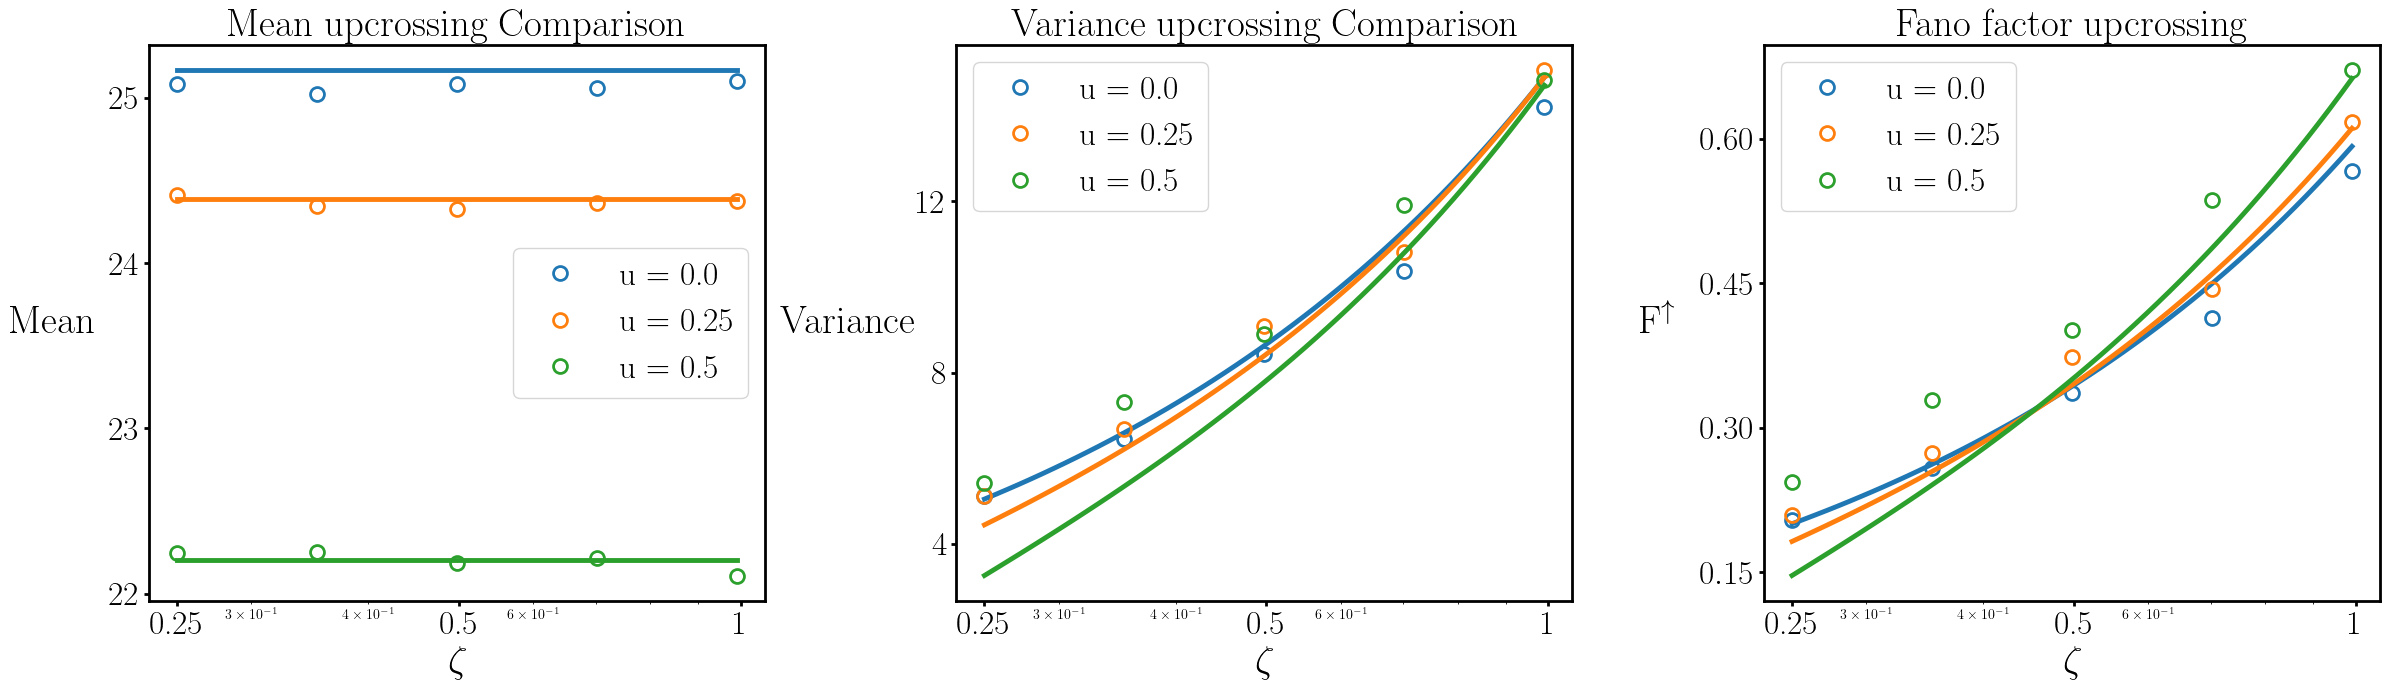

In [24]:
colors = plt.get_cmap("tab10")
# =============================================================================
# Combined Plotting Code
# =============================================================================

# Create a figure with 3 subplots (1 row, 3 columns)
# Adjust figsize as needed for aspect ratio (width might need to be ~3x height)
fig, axes = plt.subplots(1, 3, figsize=(24, 7)) # Increased width, slightly reduced height

# --- Plot Mean on the first subplot (axes[0]) ---
ax = axes[0]
for i, u in enumerate(u_list):
    analytical_mean = analytical_results[u]['mean']
    simulation_mean = simulation_results[u]['mean']
    ax.plot(zeta_vals, analytical_mean, linewidth=3.5, linestyle='-', color=colors(i), label='_nolegend_')
    ax.plot(zeta_vals_sim, simulation_mean, marker='o', markersize=10, linestyle='None',
            color=colors(i), markerfacecolor='none', markeredgewidth=2, label=f"u = {u}")

ax.set_title(f"Mean {crossing_type} Comparison", fontsize=axis_label_fontsize)
ax.set_xlabel(r"$\zeta$", fontsize=axis_label_fontsize)
ax.set_ylabel("Mean", fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=40)
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(mticker.LogLocator(base=2.0, numticks=5))
ax.yaxis.set_major_locator(mticker.MaxNLocator(num_y_ticks))
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)
ax.legend(fontsize=legend_fontsize)

# --- Plot Variance on the second subplot (axes[1]) ---
ax = axes[1]
for i, u in enumerate(u_list):
    analytical_variance = analytical_results[u]['variance']
    simulation_variance = simulation_results[u]['variance']
    ax.plot(zeta_vals, analytical_variance, linewidth=3.5, linestyle='-', color=colors(i), label='_nolegend_')
    ax.plot(zeta_vals_sim, simulation_variance, marker='o', markersize=10, linestyle='None',
            color=colors(i), markerfacecolor='none', markeredgewidth=2, label=f"u = {u}")

ax.set_title(f"Variance {crossing_type} Comparison", fontsize=axis_label_fontsize)
ax.set_xlabel(r"$\zeta$", fontsize=axis_label_fontsize)
ax.set_ylabel("Variance", fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=50) # Keep original padding
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(mticker.LogLocator(base=2.0, numticks=5))
ax.yaxis.set_major_locator(mticker.MaxNLocator(num_y_ticks))
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)
ax.legend(fontsize=legend_fontsize)

# --- Plot Fano Factor on the third subplot (axes[2]) ---
ax = axes[2]
for i, u in enumerate(u_list):
    analytical_fano = analytical_results[u]['fano_factor']
    simulation_fano = simulation_results[u]['fano_factor']
    ax.plot(zeta_vals, analytical_fano, linewidth=3.5, linestyle='-', color=colors(i), label='_nolegend_')
    ax.plot(zeta_vals_sim, simulation_fano, marker='o', markersize=10, linestyle='None',
            color=colors(i), markerfacecolor='none', markeredgewidth=2, label=f"u = {u}")

ax.set_title(f"Fano factor {crossing_type}", fontsize=axis_label_fontsize)
ax.set_xlabel(r"$\zeta$", fontsize=axis_label_fontsize)
ax.set_ylabel(fano_label, fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=30) # Keep original padding
ax.set_xscale('log')
ax.tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:g}"))
ax.xaxis.set_major_locator(mticker.LogLocator(base=2.0, numticks=5))
ax.yaxis.set_major_locator(mticker.MaxNLocator(num_y_ticks))
ax.spines['top'].set_linewidth(spine_line_width)
ax.spines['right'].set_linewidth(spine_line_width)
ax.spines['bottom'].set_linewidth(spine_line_width)
ax.spines['left'].set_linewidth(spine_line_width)
ax.legend(fontsize=legend_fontsize)

# --- Adjust layout, save the combined figure, and show ---
plt.tight_layout() # Adjust spacing between subplots

# Define folder and combined filename
folder_loc = f'../../figures/damped_harmonic_oscillator/'
os.makedirs(folder_loc, exist_ok=True)
# Use a name reflecting the combined content
file_name = f'theory_sim_mean_variance_fano_{crossing_type}'
file_save_path = os.path.join(folder_loc, file_name)

# Save the entire figure in multiple formats
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()